# IMPORT LIBRARIES

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score


# REMOVING OUTLIERS

In [2]:
df=pd.read_csv("housing.csv")

num_cols = ["price","area","bedrooms","bathrooms","stories","parking"]

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Clean dataset shape:", df.shape)


Clean dataset shape: (365, 13)


In [3]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
20,8750000,4320,3,1,2,yes,no,yes,yes,no,2,no,semi-furnished
22,8645000,8050,3,1,1,yes,yes,yes,no,yes,1,no,furnished
27,8400000,8875,3,1,1,yes,no,no,no,no,1,no,semi-furnished
40,7875000,6550,3,1,2,yes,no,yes,no,yes,0,yes,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 15 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             365 non-null    int64 
 1   area              365 non-null    int64 
 2   bedrooms          365 non-null    int64 
 3   bathrooms         365 non-null    int64 
 4   stories           365 non-null    int64 
 5   mainroad          365 non-null    object
 6   guestroom         365 non-null    object
 7   basement          365 non-null    object
 8   hotwaterheating   365 non-null    object
 9   airconditioning   365 non-null    object
 10  parking           365 non-null    int64 
 11  prefarea          365 non-null    object
 12  furnishingstatus  365 non-null    object
dtypes: int64(6), object(7)
memory usage: 39.9+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,3.650000e+02,365.000000,365.000000,365.0,365.000000,365.000000
mean,4.045012e+06,4623.810959,2.742466,1.0,1.553425,0.536986
std,1.247181e+06,1723.729307,0.624130,0.0,0.616192,0.760911
min,1.750000e+06,1650.000000,1.000000,1.0,1.000000,0.000000
25%,3.150000e+06,3460.000000,2.000000,1.0,1.000000,0.000000
50%,3.850000e+06,4079.000000,3.000000,1.0,1.000000,0.000000
75%,4.690000e+06,5800.000000,3.000000,1.0,2.000000,1.000000
max,9.100000e+06,10360.000000,4.000000,1.0,3.000000,2.000000


In [6]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
20,8750000,4320,3,1,2,yes,no,yes,yes,no,2,no,semi-furnished
22,8645000,8050,3,1,1,yes,yes,yes,no,yes,1,no,furnished
27,8400000,8875,3,1,1,yes,no,no,no,no,1,no,semi-furnished
40,7875000,6550,3,1,2,yes,no,yes,no,yes,0,yes,furnished


# SPLITING DATA

In [7]:
X=df.drop('price',axis=1)
y=df['price']

In [8]:
num_cols=['area','bedrooms','bathrooms','stories','parking']
cat_cols=['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea','furnishingstatus']

In [9]:
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),num_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# USING PIPELINE


In [11]:
pipeline=Pipeline([('preprocessing',preprocessor),('model',LinearRegression())])

### TRAINING MODEL

In [12]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [13]:
y_pred=pipeline.predict(X_test)

### CALCULATING METRICS

In [19]:
mea=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print('MAE',mea)
print('RMSE',rmse)
print('R2 score',r2)

MAE 704466.3913269148
RMSE 1036437.7288464754
R2 score 0.49653192800568047


# Compare Predicted vs Actual

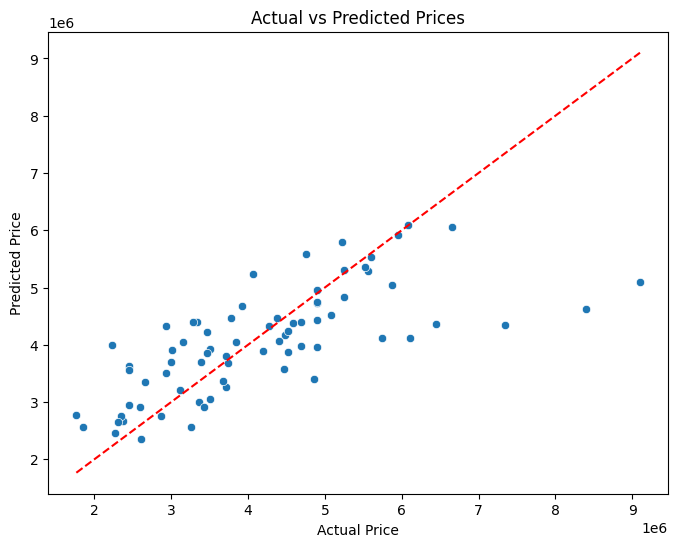

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()